In [ ]:
import warnings 
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import (
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.3f}".format)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

In [3]:
df = pd.read_csv("Global_YouTube_Statistics.csv", encoding="latin1")

print(f"Размер датасета: {df.shape[0]} строк × {df.shape[1]} столбцов")
display(df.head())

Размер датасета: 995 строк × 28 столбцов


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,lowest_yearly_earnings,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,"228,000,000,000.000",Music,T-Series,20082,India,IN,Music,1.000,1.000,1.000,"2,258,000,000.000","564,600.000","9,000,000.000","6,800,000.000","108,400,000.000","2,000,000.000","2,006.000",Mar,13.000,28.100,"1,366,417,754.000",5.360,"471,031,528.000",20.594,78.963
1,2,YouTube Movies,170000000,0.000,Film & Animation,youtubemovies,1,United States,US,Games,"4,055,159.000","7,670.000","7,423.000",12.000,0.000,0.050,0.040,0.580,NaN,"2,006.000",Mar,5.000,88.200,"328,239,523.000",14.700,"270,663,028.000",37.090,-95.713
2,3,MrBeast,166000000,"28,368,841,870.000",Entertainment,MrBeast,741,United States,US,Entertainment,48.000,1.000,1.000,"1,348,000,000.000","337,000.000","5,400,000.000","4,000,000.000","64,700,000.000","8,000,000.000","2,012.000",Feb,20.000,88.200,"328,239,523.000",14.700,"270,663,028.000",37.090,-95.713
3,4,Cocomelon - Nursery Rhymes,162000000,"164,000,000,000.000",Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,2.000,2.000,1.000,"1,975,000,000.000","493,800.000","7,900,000.000","5,900,000.000","94,800,000.000","1,000,000.000","2,006.000",Sep,1.000,88.200,"328,239,523.000",14.700,"270,663,028.000",37.090,-95.713
4,5,SET India,159000000,"148,000,000,000.000",Shows,SET India,116536,India,IN,Entertainment,3.000,2.000,2.000,"1,824,000,000.000","455,900.000","7,300,000.000","5,500,000.000","87,500,000.000","1,000,000.000","2,006.000",Sep,20.000,28.100,"1,366,417,754.000",5.360,"471,031,528.000",20.594,78.963


## Базовая проверка данных

Перед визуализациями проверим типы столбцов, пропуски и количество строк с нулевыми просмотрами. Это важно для следующих частей задания, потому что нулевые просмотры в датасете есть даже у крупных каналов, например у служебных YouTube-каналов.

In [3]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
}).sort_values("missing_%", ascending=False)

display(summary)
print("Дубликаты строк:", df.duplicated().sum())
print("Строки, где video views = 0:", int((df["video views"] == 0).sum()))

,dtype,missing_count,missing_%,n_unique
subscribers_for_last_30_days,float64,337,33.870,53
Latitude,float64,123,12.360,48
Urban_population,float64,123,12.360,48
Longitude,float64,123,12.360,48
Population,float64,123,12.360,48
Gross tertiary education enrollment (%),float64,123,12.360,47
Unemployment rate,float64,123,12.360,47
Abbreviation,object,122,12.260,49
Country,object,122,12.260,49
country_rank,float64,116,11.660,246


Дубликаты строк: 0
Строки, где video views = 0: 8


**Комментарий.** В данных 995 строк и 28 столбцов. В нескольких страновых и демографических признаках есть существенная доля пропусков, поэтому для EDA их нужно интерпретировать осторожно. В столбцах `subscribers`, `video views`, `uploads` пропусков нет, что удобно для регрессии и базовой классификации

# Задание 1. EDA

Ниже сформулированы вопросы к данным и даны ответы через визуализации.

## Вопрос 1. Какие категории каналов встречаются чаще всего?

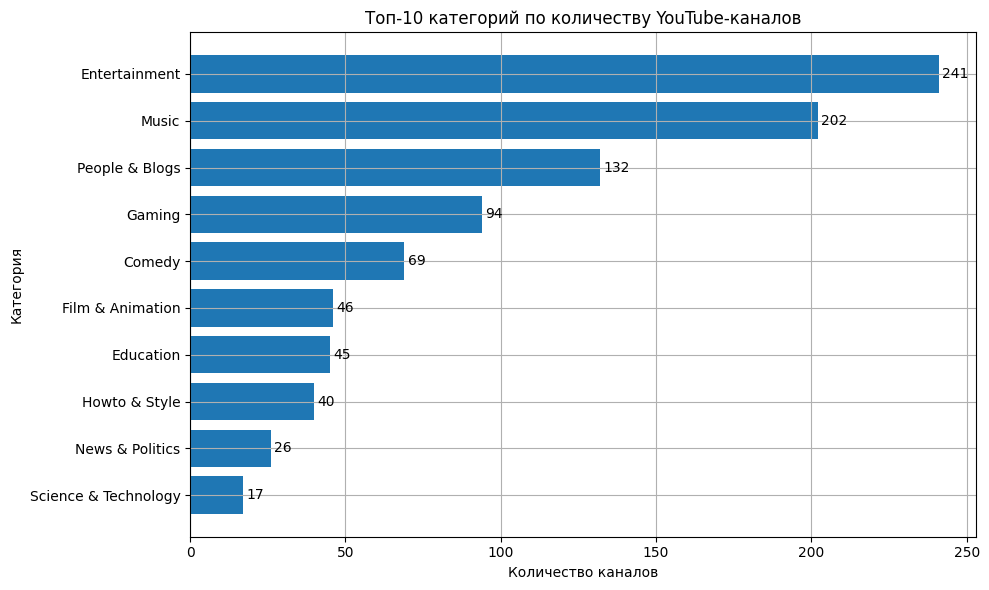

In [4]:
category_counts = df["category"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(category_counts.index, category_counts.values)
ax.set_title("Топ-10 категорий по количеству YouTube-каналов")
ax.set_xlabel("Количество каналов")
ax.set_ylabel("Категория")
for i, v in enumerate(category_counts.values):
    ax.text(v + 1, i, str(v), va="center")
plt.tight_layout()
plt.show()

**Комментарий.** Самые частые категории — **Entertainment** и **Music**. Это означает, что в датасете развлекательный и музыкальный контент представлен заметно сильнее, чем образовательный, новостной или технологический.

## Вопрос 2. Из каких стран чаще всего происходят каналы?

In [ ]:
country_counts = df["Country"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(country_counts.index, country_counts.values)
ax.set_title("Топ-10 стран по количеству каналов в датасете")
ax.set_xlabel("Количество каналов")
ax.set_ylabel("Страна")
for i, v in enumerate(country_counts.values):
    ax.text(v + 1, i, str(v), va="center")
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

**Комментарий.** По количеству каналов лидируют **United States** и **India**. Это ожидаемо: в этих странах большая аудитория, развитый рекламный рынок и много англоязычного/локального контента.

## Вопрос 3. Какие каналы лидируют по подписчикам и просмотрам?

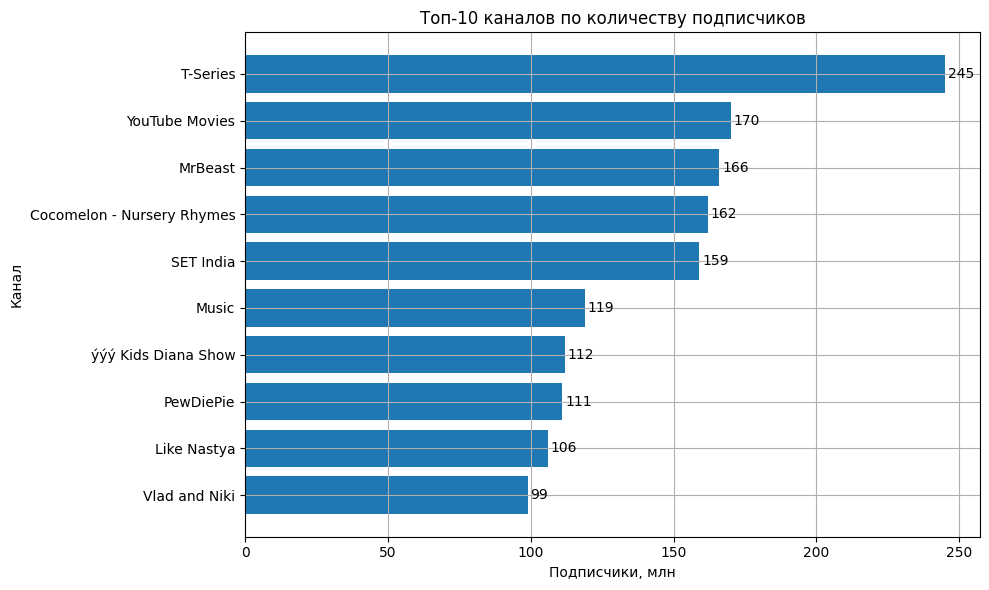

In [6]:
top_subs = df.nlargest(10, "subscribers").sort_values("subscribers")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_subs["Youtuber"], top_subs["subscribers"] / 1e6)
ax.set_title("Топ-10 каналов по количеству подписчиков")
ax.set_xlabel("Подписчики, млн")
ax.set_ylabel("Канал")
for i, v in enumerate(top_subs["subscribers"] / 1e6):
    ax.text(v + 1, i, f"{v:.0f}", va="center")
plt.tight_layout()
plt.show()

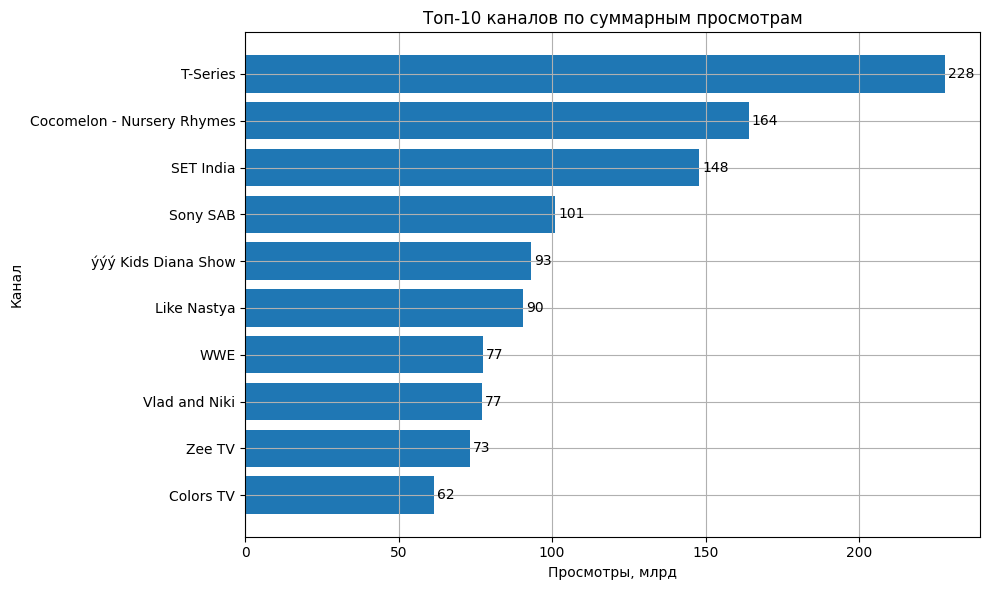

In [7]:
top_views = df.nlargest(10, "video views").sort_values("video views")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_views["Youtuber"], top_views["video views"] / 1e9)
ax.set_title("Топ-10 каналов по суммарным просмотрам")
ax.set_xlabel("Просмотры, млрд")
ax.set_ylabel("Канал")
for i, v in enumerate(top_views["video views"] / 1e9):
    ax.text(v + 1, i, f"{v:.0f}", va="center")
plt.tight_layout()
plt.show()

**Комментарий.** Лидеры по подписчикам и по просмотрам пересекаются, но не полностью совпадают. Это говорит о том, что подписчики и просмотры связаны, но не являются идентичными показателями: детские, музыкальные и развлекательные каналы могут набирать огромные просмотры даже при иной структуре подписчиков.

## Вопрос 4. Есть ли связь между количеством просмотров и количеством подписчиков?

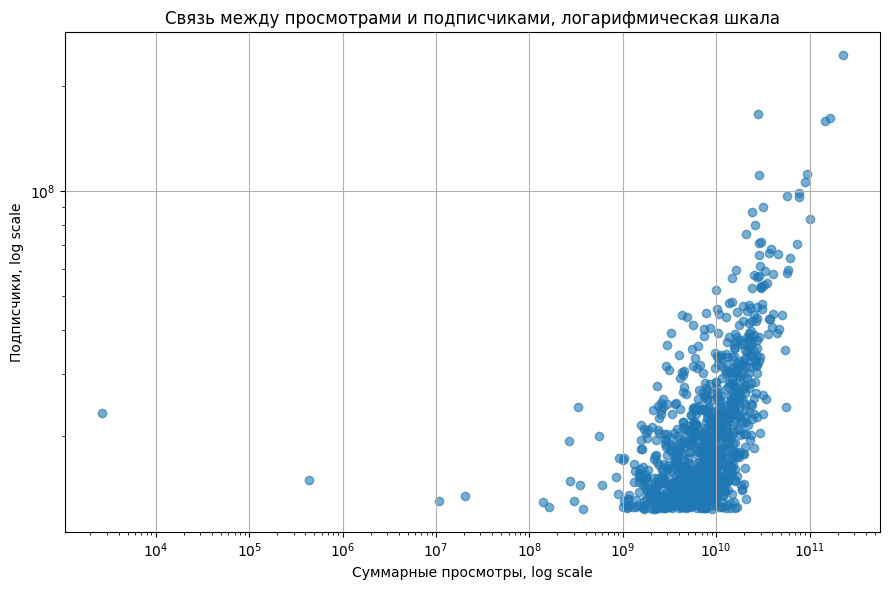

Корреляция Пирсона без нулевых просмотров: 0.8243


In [8]:
nonzero_views = df[df["video views"] > 0].copy()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(nonzero_views["video views"], nonzero_views["subscribers"], alpha=0.6)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Связь между просмотрами и подписчиками, логарифмическая шкала")
ax.set_xlabel("Суммарные просмотры, log scale")
ax.set_ylabel("Подписчики, log scale")
plt.tight_layout()
plt.show()

corr_views_subs = nonzero_views["video views"].corr(nonzero_views["subscribers"])
print(f"Корреляция Пирсона без нулевых просмотров: {corr_views_subs:.4f}")

**Комментарий.** Визуализация показывает выраженную положительную связь: чем больше суммарных просмотров, тем чаще канал имеет больше подписчиков. При этом разброс остается большим, поэтому только по просмотрам нельзя идеально предсказать число подписчиков.

## Вопрос 5. Какие категории имеют наибольшую медиану подписчиков?

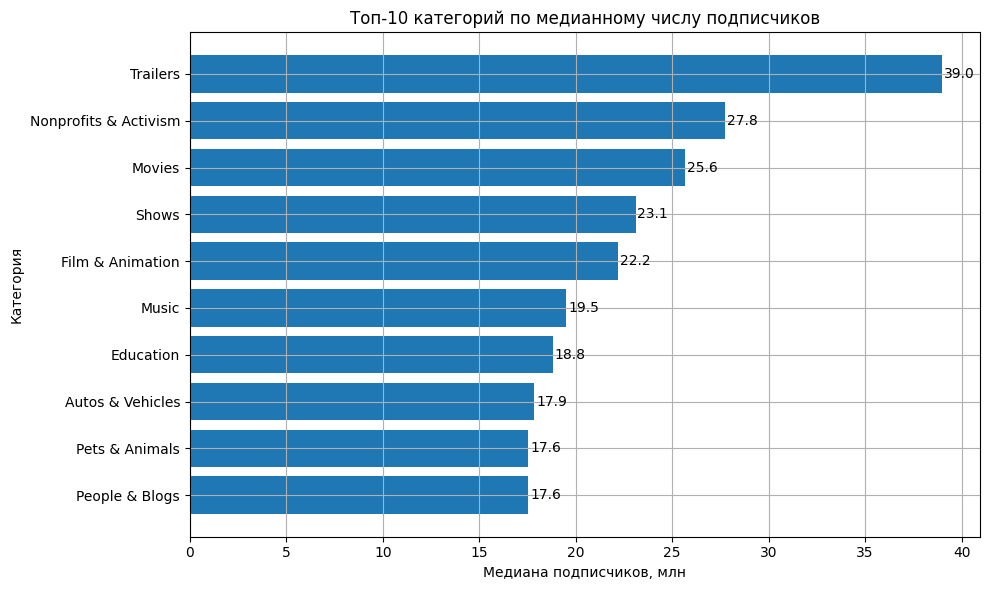

In [9]:
cat_median_subs = (
    df.dropna(subset=["category"])
      .groupby("category")["subscribers"]
      .median()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cat_median_subs.index, cat_median_subs.values / 1e6)
ax.set_title("Топ-10 категорий по медианному числу подписчиков")
ax.set_xlabel("Медиана подписчиков, млн")
ax.set_ylabel("Категория")
for i, v in enumerate(cat_median_subs.values / 1e6):
    ax.text(v + 0.1, i, f"{v:.1f}", va="center")
plt.tight_layout()
plt.show()

**Комментарий.** Медиана полезнее среднего, потому что топовые каналы создают сильные выбросы. На графике видно, что отдельные категории могут иметь меньше каналов, но более крупную типичную аудиторию.

## Вопрос 6. Связано ли количество загруженных видео с суммарными просмотрами?

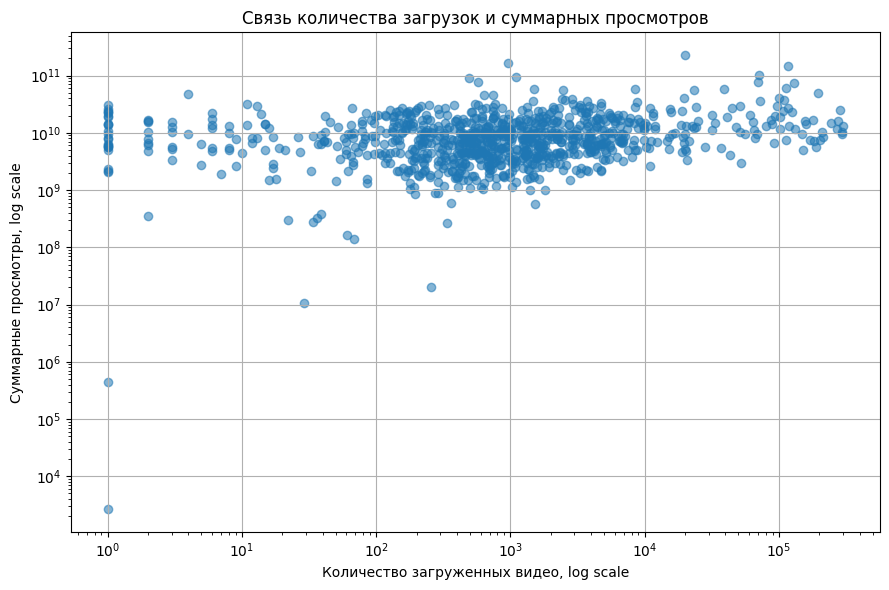

Корреляция uploads и video views: 0.1634


In [10]:
uploads_views = df[(df["uploads"] > 0) & (df["video views"] > 0)].copy()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(uploads_views["uploads"], uploads_views["video views"], alpha=0.55)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Связь количества загрузок и суммарных просмотров")
ax.set_xlabel("Количество загруженных видео, log scale")
ax.set_ylabel("Суммарные просмотры, log scale")
plt.tight_layout()
plt.show()

print("Корреляция uploads и video views:", round(uploads_views["uploads"].corr(uploads_views["video views"]), 4))

**Комментарий.** Связь есть, но она слабее, чем связь между просмотрами и подписчиками. Большое число загруженных видео само по себе не гарантирует высокий общий охват: важны категория, формат, аудитория и популярность конкретных роликов.

## Вопрос 7. В какие годы было создано больше всего каналов из датасета?

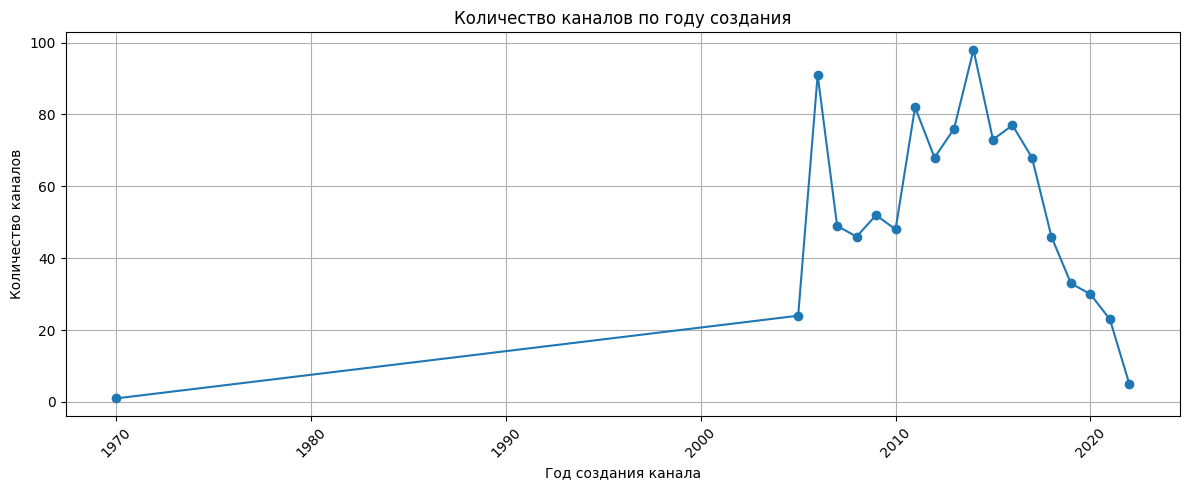

In [11]:
year_counts = df["created_year"].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(year_counts.index, year_counts.values, marker="o")
ax.set_title("Количество каналов по году создания")
ax.set_xlabel("Год создания канала")
ax.set_ylabel("Количество каналов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Комментарий.** Большая часть крупнейших каналов была создана в период активного роста YouTube как платформы. Более ранние каналы получили преимущество накопления аудитории и просмотров.

## Вопрос 8. В каких категориях выше оценочные ежемесячные доходы?

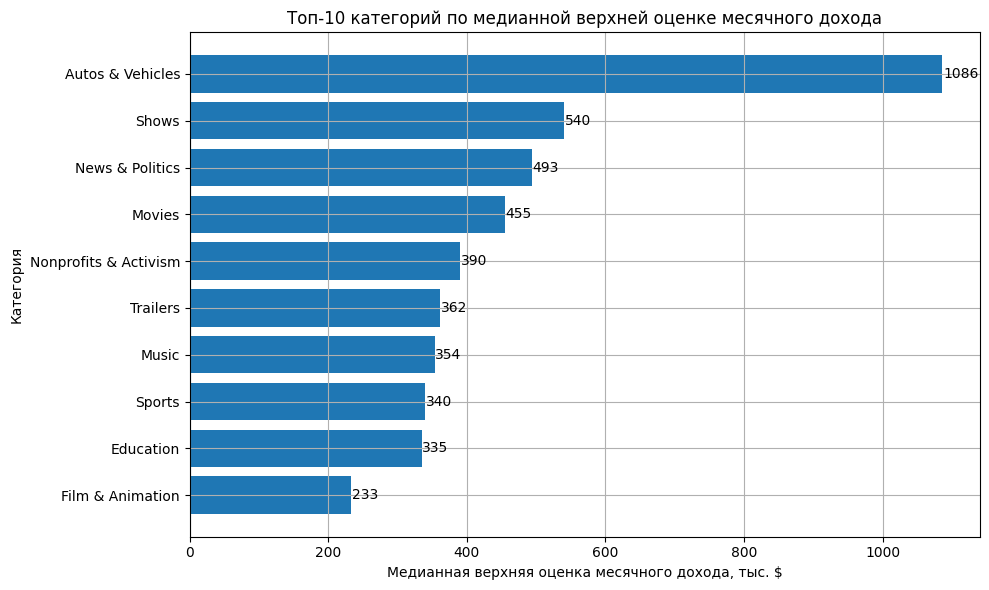

In [12]:
earnings_by_category = (
    df.dropna(subset=["category"])
      .groupby("category")["highest_monthly_earnings"]
      .median()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(earnings_by_category.index, earnings_by_category.values / 1_000)
ax.set_title("Топ-10 категорий по медианной верхней оценке месячного дохода")
ax.set_xlabel("Медианная верхняя оценка месячного дохода, тыс. $")
ax.set_ylabel("Категория")
for i, v in enumerate(earnings_by_category.values / 1_000):
    ax.text(v + 1, i, f"{v:.0f}", va="center")
plt.tight_layout()
plt.show()

**Комментарий.** Доходы сильно связаны с просмотрами, поэтому категории с большим количеством массового контента имеют более высокие оценки. Следует помнить, что это не фактическая выручка, а оценочный диапазон.

## Матрица корреляций

Матрица ниже помогает найти линейные взаимосвязи между числовыми признаками. Для читаемости взяты основные числовые столбцы, наиболее релевантные заданию.

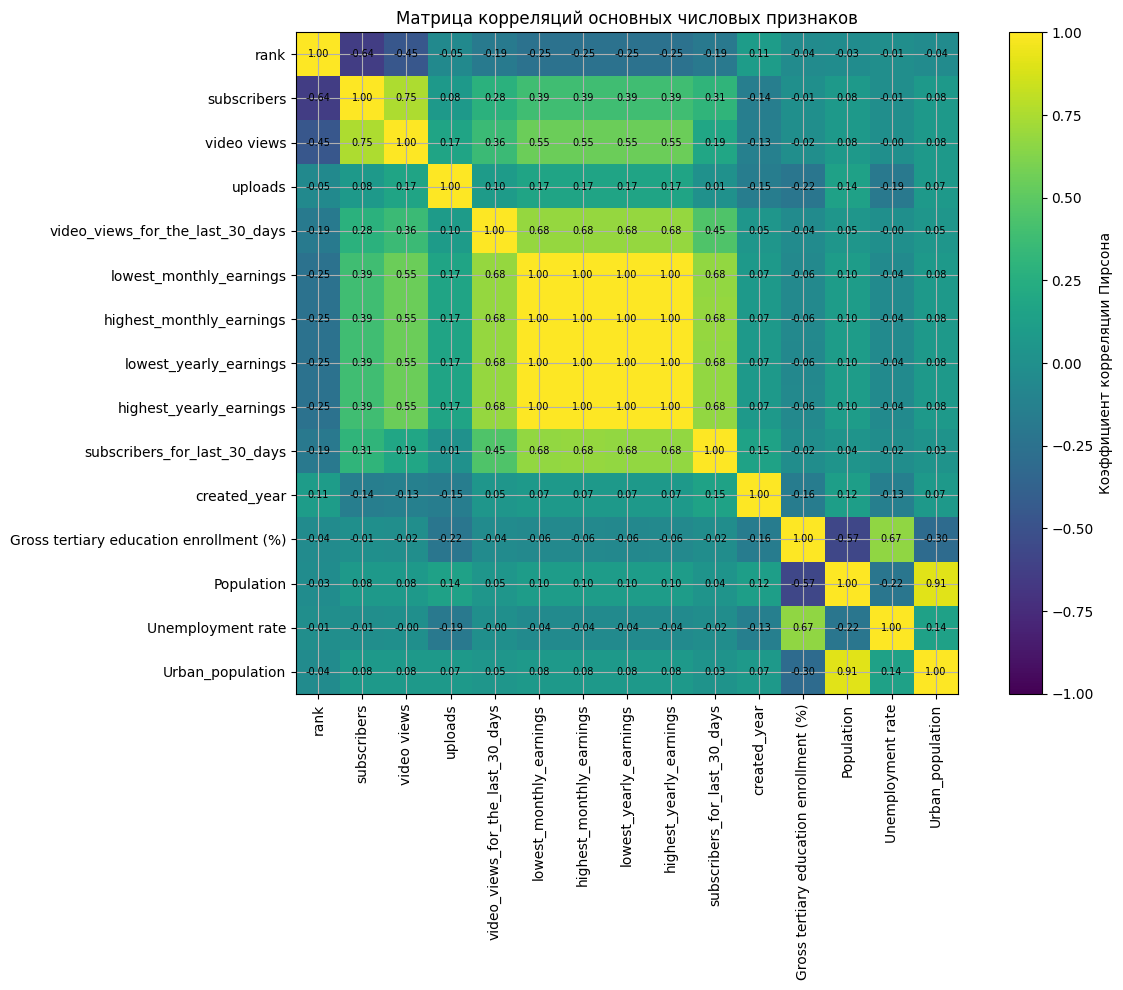

In [13]:
corr_cols = [
    "rank",
    "subscribers",
    "video views",
    "uploads",
    "video_views_for_the_last_30_days",
    "lowest_monthly_earnings",
    "highest_monthly_earnings",
    "lowest_yearly_earnings",
    "highest_yearly_earnings",
    "subscribers_for_last_30_days",
    "created_year",
    "Gross tertiary education enrollment (%)",
    "Population",
    "Unemployment rate",
    "Urban_population",
]

corr_df = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(corr_df, vmin=-1, vmax=1)
ax.set_title("Матрица корреляций основных числовых признаков")
ax.set_xticks(range(len(corr_df.columns)))
ax.set_yticks(range(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, rotation=90)
ax.set_yticklabels(corr_df.columns)

for i in range(len(corr_df.columns)):
    for j in range(len(corr_df.columns)):
        value = corr_df.iloc[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Коэффициент корреляции Пирсона")
plt.tight_layout()
plt.show()

**Комментарий.** Наиболее заметная положительная связь — между `subscribers` и `video views`. Также ожидаемо очень сильно коррелируют нижние/верхние оценки месячного и годового дохода, потому что они являются разными масштабами одной оценочной величины.

# Задание 2. Корреляционный анализ и линейная регрессия

Используем только два столбца:

- `video views` — признак **X**;
- `subscribers` — целевая переменная **y**.

Сначала убираем строки, где `video views = 0`, как требуется в задании.

In [14]:
reg_df = df[["video views", "subscribers"]].copy()
reg_df_nonzero = reg_df[reg_df["video views"] != 0].copy()

print("Размер до фильтрации:", reg_df.shape)
print("Размер после удаления нулевых просмотров:", reg_df_nonzero.shape)

pearson_corr = reg_df_nonzero["video views"].corr(reg_df_nonzero["subscribers"], method="pearson")
print(f"Коэффициент корреляции Пирсона: {pearson_corr:.4f}")

Размер до фильтрации: (995, 2)
Размер после удаления нулевых просмотров: (987, 2)
Коэффициент корреляции Пирсона: 0.8243


In [15]:
X = reg_df_nonzero[["video views"]]
y = reg_df_nonzero["subscribers"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=13
)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)
r2_nonzero = r2_score(y_test, y_pred)

print(f"R² на тестовой выборке без нулевых просмотров: {r2_nonzero:.4f}")
print(f"Коэффициент наклона: {lin_reg.coef_[0]:.10f}")
print(f"Свободный член: {lin_reg.intercept_:,.2f}")

R² на тестовой выборке без нулевых просмотров: 0.7366
Коэффициент наклона: 0.0009522287
Свободный член: 12,101,056.74


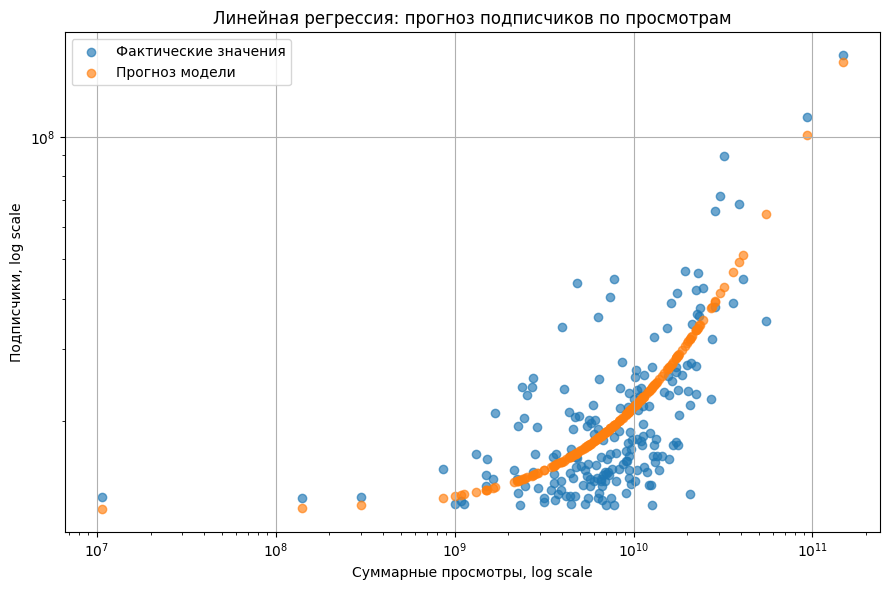

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_test["video views"], y_test, alpha=0.65, label="Фактические значения")
ax.scatter(X_test["video views"], y_pred, alpha=0.65, label="Прогноз модели")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Линейная регрессия: прогноз подписчиков по просмотрам")
ax.set_xlabel("Суммарные просмотры, log scale")
ax.set_ylabel("Подписчики, log scale")
ax.legend()
plt.tight_layout()
plt.show()

**Комментарий.** Корреляция высокая, и линейная регрессия объясняет значительную часть вариации числа подписчиков. Но по графику видно, что разброс вокруг линии прогноза остается: одинаковые просмотры могут соответствовать разному числу подписчиков.

## Что изменится, если не удалять нулевые просмотры?

In [17]:
X_all = reg_df[["video views"]]
y_all = reg_df["subscribers"]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=13
)

lin_reg_all = LinearRegression()
lin_reg_all.fit(X_train_all, y_train_all)

y_pred_all = lin_reg_all.predict(X_test_all)
r2_with_zero = r2_score(y_test_all, y_pred_all)
pearson_corr_all = reg_df["video views"].corr(reg_df["subscribers"], method="pearson")

comparison_reg = pd.DataFrame({
    "Вариант": ["Без нулевых просмотров", "С нулевыми просмотрами"],
    "Pearson corr": [pearson_corr, pearson_corr_all],
    "R² на тесте": [r2_nonzero, r2_with_zero],
})

display(comparison_reg)

,Вариант,Pearson corr,R² на тесте
0,Без нулевых просмотров,0.824,0.737
1,С нулевыми просмотрами,0.751,0.790


In [18]:
zero_views_rows = df.loc[df["video views"] == 0, [
    "rank", "Youtuber", "subscribers", "video views", "category", "uploads", "Country"
]]
display(zero_views_rows)

,rank,Youtuber,subscribers,video views,category,uploads,Country
1,2,YouTube Movies,170000000,0.000,Film & Animation,1,United States
5,6,Music,119000000,0.000,NaN,0,NaN
12,13,Gaming,93600000,0.000,NaN,0,NaN
18,19,Sports,75000000,0.000,NaN,3,United States
102,103,News,36300000,0.000,NaN,0,NaN
173,174,Popular on YouTube,29300000,0.000,NaN,3,NaN
360,361,Minecraft - Topic,20900000,0.000,NaN,0,NaN
592,593,Live,16100000,0.000,NaN,0,NaN


**Вывод по заданию 2.** После удаления нулевых просмотров коэффициент Пирсона равен примерно **0.8243**, а качество линейной регрессии на тестовой выборке — **R² ≈ 0.7366**. Если не удалять строки с нулевыми просмотрами, корреляция падает примерно до **0.7510**, но R² на данном разбиении становится **≈ 0.7903**. Это не означает, что нулевые просмотры полезны: среди них есть крупные служебные каналы с десятками миллионов подписчиков, то есть это скорее аномалии/особые случаи, которые искажают интерпретацию зависимости.

# Задание 3. Классификация

Нужно определить две самые популярные категории, отфильтровать датасет по ним, взять признаки:

- `video views`,
- `subscribers`,
- `uploads`,

убрать строки с нулевыми просмотрами, закодировать `category` через `LabelEncoder`, затем обучить логистическую регрессию.

In [19]:
top_2_categories = df["category"].dropna().value_counts().head(2).index.tolist()
print("Две самые популярные категории:", top_2_categories)

class_df = df[df["category"].isin(top_2_categories)].copy()
class_df = class_df[class_df["video views"] != 0].copy()

features = ["video views", "subscribers", "uploads"]
X = class_df[features]

le = LabelEncoder()
y = le.fit_transform(class_df["category"])
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print("Размер выборки для классификации:", class_df.shape)
print("Распределение классов:")
display(class_df["category"].value_counts())
print("Кодирование классов:", label_mapping)

Две самые популярные категории: ['Entertainment', 'Music']
Размер выборки для классификации: (443, 28)
Распределение классов:


category
Entertainment    241
Music            202
Name: count, dtype: int64

Кодирование классов: {'Entertainment': np.int64(0), 'Music': np.int64(1)}


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=13, stratify=y
)

log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=13)
)

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

accuracy_base = accuracy_score(y_test, y_pred)
print(f"Accuracy логистической регрессии: {accuracy_base:.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy логистической регрессии: 0.6742
               precision    recall  f1-score   support

Entertainment       0.65      0.85      0.74        48
        Music       0.73      0.46      0.57        41

     accuracy                           0.67        89
    macro avg       0.69      0.66      0.65        89
 weighted avg       0.69      0.67      0.66        89



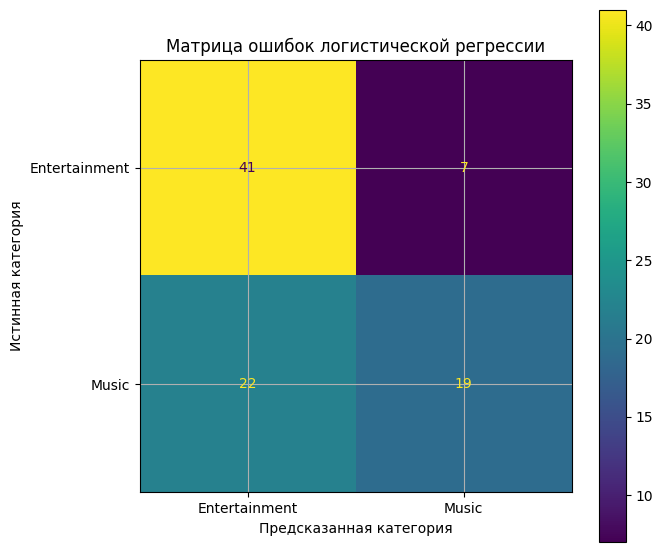

In [21]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
ax.set_title("Матрица ошибок логистической регрессии")
ax.set_xlabel("Предсказанная категория")
ax.set_ylabel("Истинная категория")
plt.tight_layout()
plt.show()

**Комментарий.** Модель разделяет две самые частые категории — **Entertainment** и **Music** — лучше случайного угадывания, но не идеально. Это ожидаемо: признаки `video views`, `subscribers`, `uploads` описывают масштаб канала, но не содержание канала напрямую.

## Изменится ли точность, если выбрать другие признаки?

Проверим несколько альтернативных наборов признаков. Для наборов, где могут быть пропуски, используем медианное заполнение, затем масштабирование и логистическую регрессию.

In [22]:
feature_sets = {
    "baseline: views + subscribers + uploads": [
        "video views", "subscribers", "uploads"
    ],
    "recent activity": [
        "video_views_for_the_last_30_days", "subscribers_for_last_30_days", "uploads"
    ],
    "earnings": [
        "lowest_monthly_earnings", "highest_monthly_earnings",
        "lowest_yearly_earnings", "highest_yearly_earnings"
    ],
    "ranks": [
        "video_views_rank", "country_rank", "channel_type_rank"
    ],
    "extended numeric": [
        "video views", "subscribers", "uploads",
        "video_views_for_the_last_30_days", "subscribers_for_last_30_days",
        "highest_monthly_earnings", "created_year"
    ],
    "country context": [
        "Gross tertiary education enrollment (%)", "Population",
        "Unemployment rate", "Urban_population", "Latitude", "Longitude"
    ],
}

rows = []
for name, cols in feature_sets.items():
    X_alt = class_df[cols].apply(pd.to_numeric, errors="coerce")
    X_train_alt, X_test_alt, y_train_alt, y_test_alt = train_test_split(
        X_alt, y, test_size=0.2, random_state=13, stratify=y
    )
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=13)),
    ])
    model.fit(X_train_alt, y_train_alt)
    pred_alt = model.predict(X_test_alt)
    rows.append({
        "Набор признаков": name,
        "Accuracy": accuracy_score(y_test_alt, pred_alt),
        "Количество признаков": len(cols),
    })

feature_comparison = pd.DataFrame(rows).sort_values("Accuracy", ascending=False)
display(feature_comparison)

,Набор признаков,Accuracy,Количество признаков
4,extended numeric,0.775,7
1,recent activity,0.719,3
0,baseline: views + subscribers + uploads,0.674,3
2,earnings,0.539,4
3,ranks,0.539,3
5,country context,0.494,6


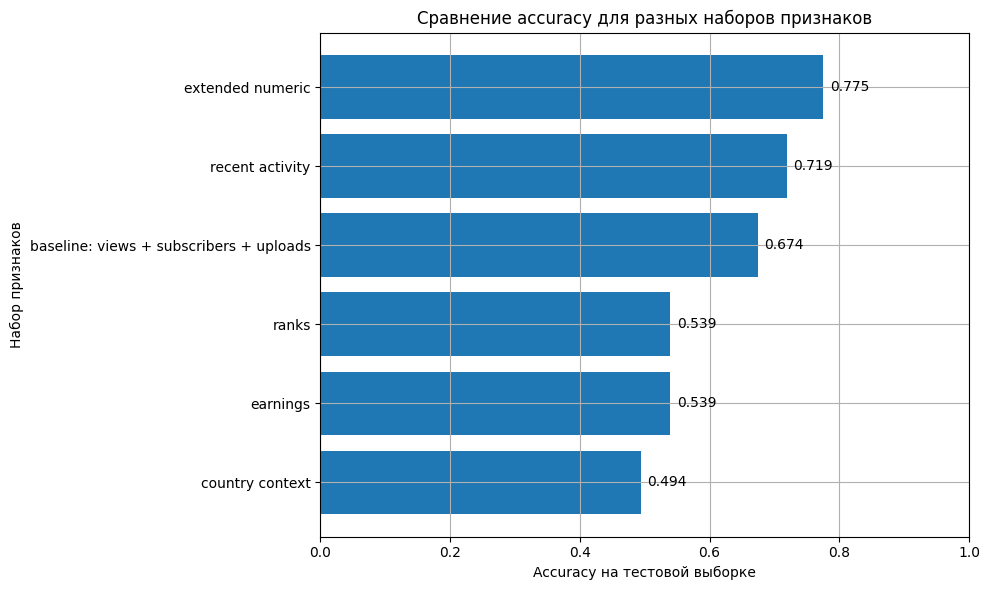

In [23]:
plot_df = feature_comparison.sort_values("Accuracy")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["Набор признаков"], plot_df["Accuracy"])
ax.set_title("Сравнение accuracy для разных наборов признаков")
ax.set_xlabel("Accuracy на тестовой выборке")
ax.set_ylabel("Набор признаков")
ax.set_xlim(0, 1)
for i, v in enumerate(plot_df["Accuracy"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

**Вывод по заданию 3.** Да, точность меняется при выборе других признаков. Базовый набор `video views`, `subscribers`, `uploads` дает accuracy около **0.6742**. Расширенный набор числовых признаков в этом эксперименте дает более высокую accuracy — около **0.7753**, а страновые признаки и ранги работают хуже. Причина: базовые признаки описывают масштаб канала, а дополнительные признаки о недавней активности и доходах добавляют информацию, которая помогает отличить музыкальные каналы от развлекательных.

# Общие выводы

1. В датасете доминируют категории **Entertainment** и **Music**; по странам лидируют **United States** и **India**.
2. Между `video views` и `subscribers` есть сильная положительная связь: Pearson без нулевых просмотров ≈ **0.8243**.
3. Линейная регрессия по одному признаку `video views` дает **R² ≈ 0.7366** после удаления нулевых просмотров.
4. Если нулевые просмотры не удалять, корреляция становится ниже, но R² на конкретном разбиении выше; такие строки лучше рассматривать как аномальные/служебные случаи.
5. Логистическая регрессия по признакам `video views`, `subscribers`, `uploads` различает две самые частые категории с accuracy ≈ **0.6742**.
6. При добавлении других информативных числовых признаков accuracy может измениться; в эксперименте расширенный набор повысил accuracy до ≈ **0.7753**.